In [1]:
# !pip install anomalib
# !pip install matplotlib
# !pip install numpy
# !pip install tensorboard
# !pip install torch==2.7.1 torchvision==0.22.1 torchaudio==2.7.1 --index-url https://download.pytorch.org/whl/cu128
# !pip install kaggle


In [2]:
import copy
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
import torch.optim as optim
import torch.nn.functional as torch_f
from torch.optim.lr_scheduler import MultiStepLR

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

from anomalib.metrics.aupro import _AUPRO as DirectAUPRO
from anomalib.models.image.supersimplenet.loss import SSNLoss
from anomalib.models.image.supersimplenet.torch_model import SupersimplenetModel


c:\Users\AERO\Desktop\master_work\Experiments\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import sys
import torch

print("Python executable:", sys.executable)
print("torch:", torch.__version__)
print("torch.version.cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("cuda device:", torch.cuda.get_device_name(0))

assert "+cu128" in torch.__version__, "Expected CUDA 12.8 PyTorch wheel, e.g. torch==2.7.1+cu128"
assert torch.cuda.is_available(), "CUDA is not visible from this notebook kernel"


Python executable: c:\Users\AERO\Desktop\master_work\Experiments\.venv\Scripts\python.exe
torch: 2.7.1+cu128
torch.version.cuda: 12.8
cuda available: True
cuda device: NVIDIA GeForce RTX 3070 Ti Laptop GPU


# Конфигурация

Printer-версия повторяет свежий MVTec baseline, но использует pseudo-class `printer` и структуру `processed_printer_dataset`.


Для предобработки картинок и постобработке карт аномалий


In [9]:
def resolve_project_path(*parts):
    relative = Path(*parts)
    cwd = Path.cwd().resolve()
    candidates = [cwd / relative, cwd.parent / relative]
    for candidate in candidates:
        if candidate.exists():
            return str(candidate)
    return str(candidates[0])


dataset_path = resolve_project_path("datasets", "processed_printer_dataset")
class_name = "printer"
image_size = 256
random_seed = 42

# Diverse caps for quick, less redundant runs. Set any of these to None for the full split.
validation_date_count = 1
max_train_images = 800
max_val_images = 200
max_train_images_per_date = None
max_val_images_per_date = None
max_classification_normals = 200
max_classification_anomalies = 200
coordinate_bin_size = 512
num_train_epochs = 70

quality_metric_names = ["image_roc_auc_raw", "pixel_aupro"]

random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_seed)

print(f"Dataset path: {dataset_path}")


Dataset path: C:\Users\AERO\Desktop\master_work\Experiments\datasets\processed_printer_dataset


In [10]:
def get_augmented_transformer(image_size):
    return transforms.Compose([
        transforms.RandomResizedCrop((image_size, image_size), scale=(0.9, 1.0), ratio=(1, 1)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


def get_transformer(image_size):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


def get_mask_transformer(image_size):
    return transforms.Compose([
        transforms.Resize((image_size, image_size), interpolation=transforms.InterpolationMode.NEAREST),
        transforms.ToTensor(),
    ])


def denormalize_image(tensor):
    denormalize = transforms.Normalize(
        mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
        std=[1 / 0.229, 1 / 0.224, 1 / 0.225],
    )
    return torch.clamp(denormalize(tensor.detach().cpu()), 0.0, 1.0)


def show_tensor(tensor):
    transforms.ToPILImage()(tensor.detach().cpu()).show()


def postprocess_anomaly_map(anomaly_map, true_img_size):
    while anomaly_map.ndim < 4:
        anomaly_map = anomaly_map.unsqueeze(0)

    upsampled_mask = torch_f.interpolate(
        anomaly_map,
        size=true_img_size,
        mode="bilinear",
        align_corners=False,
    )
    return upsampled_mask.squeeze()


In [11]:
# path = os.path.join(dataset_path, class_name, "test", test_groups[0], "003.png")
# print(path)
# img = Image.open(path).convert('RGB')
# img = get_transformer(256)(img)
# print(img.shape)
# # img = img[0, :, :]
# img = postprocess_anomaly_map(img.unsqueeze(0), true_img_size=(900, 900))
# print(img.shape)
# print(img.max())
# print(img.dtype)
# show_tensor(img)


Датасеты


In [12]:
IMAGE_EXTENSIONS = (".png", ".jpg", ".jpeg")


def is_image_file(name):
    return str(name).lower().endswith(IMAGE_EXTENSIONS) and not os.path.basename(str(name)).startswith("._")


def list_image_files(root_dir, recursive=False):
    if not os.path.isdir(root_dir):
        return []
    if recursive:
        paths = []
        for current_dir, _, files in os.walk(root_dir):
            paths.extend(os.path.join(current_dir, name) for name in sorted(files) if is_image_file(name))
        return sorted(paths)
    return sorted(os.path.join(root_dir, name) for name in os.listdir(root_dir) if is_image_file(name))


def parse_fragment_name(path, coord_bin_size=512):
    stem = os.path.splitext(os.path.basename(path))[0]
    parts = stem.split("_")
    frame_id = parts[0] if parts else stem
    object_id = "whole"
    for part in parts:
        if part.startswith("obj") and part[3:].isdigit():
            object_id = part
            break

    coord_bin = (-1, -1)
    if "tile" in parts:
        tile_idx = parts.index("tile")
        if tile_idx + 2 < len(parts) and parts[tile_idx + 1].isdigit() and parts[tile_idx + 2].isdigit():
            x = int(parts[tile_idx + 1])
            y = int(parts[tile_idx + 2])
            coord_bin = (x // coord_bin_size, y // coord_bin_size)
    return frame_id, object_id, coord_bin


def diverse_sample_paths(paths, max_items=None, seed=42, salt="", coord_bin_size=512):
    paths = sorted(paths)
    if max_items is None or len(paths) <= max_items:
        return paths

    rng = random.Random(f"{seed}_{salt}")
    grouped = {}
    for path in paths:
        frame_id, object_id, coord_bin = parse_fragment_name(path, coord_bin_size=coord_bin_size)
        grouped.setdefault((frame_id, object_id), {}).setdefault(coord_bin, []).append(path)

    group_keys = sorted(grouped)
    rng.shuffle(group_keys)
    queues = {}
    for group_key in group_keys:
        coord_keys = sorted(grouped[group_key])
        rng.shuffle(coord_keys)
        queue = []
        for coord_key in coord_keys:
            coord_paths = sorted(grouped[group_key][coord_key])
            rng.shuffle(coord_paths)
            queue.extend(coord_paths)
        queues[group_key] = queue

    selected = []
    while len(selected) < max_items and queues:
        for group_key in list(group_keys):
            queue = queues.get(group_key)
            if not queue:
                queues.pop(group_key, None)
                continue
            selected.append(queue.pop(0))
            if len(selected) >= max_items:
                break
    return sorted(selected)


class PrinterTrainDataset(Dataset):
    def __init__(self, root_dir, transform=None, include_dates=None, max_images=None, max_images_per_date=None, seed=42, coord_bin_size=512):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.dates = []

        include_dates = set(include_dates) if include_dates is not None else None
        if not os.path.isdir(root_dir):
            print(f"Training root does not exist yet: {root_dir}")
            return

        for date_dir in sorted(os.listdir(root_dir)):
            if include_dates is not None and date_dir not in include_dates:
                continue
            objects_dir = os.path.join(root_dir, date_dir, "objects_parts")
            date_paths = diverse_sample_paths(
                list_image_files(objects_dir),
                max_items=max_images_per_date,
                seed=seed,
                salt=date_dir,
                coord_bin_size=coord_bin_size,
            )
            self.image_paths.extend(date_paths)
            self.dates.extend([date_dir] * len(date_paths))

        if max_images is not None and len(self.image_paths) > max_images:
            selected = set(diverse_sample_paths(
                self.image_paths,
                max_items=max_images,
                seed=seed,
                salt="total_train_subset",
                coord_bin_size=coord_bin_size,
            ))
            self.image_paths, self.dates = zip(*[
                (path, date) for path, date in zip(self.image_paths, self.dates) if path in selected
            ])
            self.image_paths = list(self.image_paths)
            self.dates = list(self.dates)

        print(f"Loaded {len(self.image_paths)} normal object fragments from {self.root_dir}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image


class PrinterClassificationDataset(Dataset):
    def __init__(
        self,
        train_root,
        anomalies_root,
        transform=None,
        normal_dates=None,
        max_normal_images=None,
        max_anomaly_images=None,
        seed=42,
        coord_bin_size=512,
    ):
        self.transform = transform
        self.samples = []
        normal_dates = set(normal_dates) if normal_dates is not None else None

        normal_candidates = []
        if os.path.isdir(train_root):
            for date_dir in sorted(os.listdir(train_root)):
                if normal_dates is not None and date_dir not in normal_dates:
                    continue
                normal_dir = os.path.join(train_root, date_dir, "objects_parts")
                normal_candidates.extend((path, date_dir) for path in list_image_files(normal_dir))
        normal_paths = diverse_sample_paths(
            [path for path, _ in normal_candidates],
            max_items=max_normal_images,
            seed=seed,
            salt="classification_normals",
            coord_bin_size=coord_bin_size,
        )
        normal_dates_by_path = {path: date_dir for path, date_dir in normal_candidates}
        self.samples.extend(
            (path, 0, "good", f"{normal_dates_by_path[path]}_{os.path.basename(path)}")
            for path in normal_paths
        )

        anomaly_dir = os.path.join(anomalies_root, "objects_parts")
        anomaly_paths = diverse_sample_paths(
            list_image_files(anomaly_dir),
            max_items=max_anomaly_images,
            seed=seed,
            salt="printer_anomaly",
            coord_bin_size=coord_bin_size,
        )
        self.samples.extend((path, 1, "printer_anomaly", os.path.basename(path)) for path in anomaly_paths)

        self.images = [sample[0] for sample in self.samples]
        self.labels = [sample[1] for sample in self.samples]
        self.defect_types = [sample[2] for sample in self.samples]
        self.names = [sample[3] for sample in self.samples]
        print(
            "Loaded image-level candidates: "
            f"normal={sum(label == 0 for label in self.labels)}, anomaly={sum(label == 1 for label in self.labels)}"
        )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label, defect_type, name = self.samples[idx]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label, defect_type, name


class PrinterUnlabeledImageDataset(Dataset):
    def __init__(self, root_dir, transform=None, max_images=None, seed=42):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = diverse_sample_paths(list_image_files(root_dir), max_items=max_images, seed=seed, salt=root_dir, coord_bin_size=coordinate_bin_size)
        self.names = [os.path.basename(path) for path in self.image_paths]
        print(f"Loaded {len(self.image_paths)} unlabeled images from {self.root_dir}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, self.names[idx]


class PrinterSegmentationDataset(Dataset):
    # Future hook for true anomaly masks. Object masks are not anomaly masks.

    def __init__(self, root_dir, img_transform=None, mask_transform=None, masks_dir_name="ground_truth", strict_masks=False):
        self.img_transform = img_transform
        self.mask_transform = mask_transform
        self.base_transform = transforms.ToTensor()
        self.images = []
        self.masks = []
        self.defect_types = []
        self.names = []

        imgs_path = os.path.join(root_dir, "objects_parts")
        masks_path = os.path.join(root_dir, masks_dir_name)
        missing_masks = []

        for image_path in list_image_files(imgs_path):
            name = os.path.basename(image_path)
            stem, ext = os.path.splitext(name)
            candidates = [os.path.join(masks_path, f"{stem}_mask{ext}"), os.path.join(masks_path, name)]
            mask_path = next((candidate for candidate in candidates if os.path.exists(candidate)), None)
            if mask_path is None:
                missing_masks.append(image_path)
                continue
            self.images.append(image_path)
            self.masks.append(mask_path)
            self.defect_types.append("printer_anomaly")
            self.names.append(name)

        if missing_masks and strict_masks:
            preview = "\n".join(missing_masks[:5])
            raise FileNotFoundError(f"Anomaly masks were not found for {len(missing_masks)} images:\n{preview}")
        if missing_masks:
            print(f"Skipped {len(missing_masks)} anomaly images without anomaly masks")
        print(f"Loaded {len(self.images)} segmentation samples with real anomaly masks")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert("RGB")
        mask = Image.open(self.masks[idx]).convert("L")
        image = self.img_transform(image) if self.img_transform else self.base_transform(image)
        mask = self.mask_transform(mask) if self.mask_transform else self.base_transform(mask)
        return image, mask, self.defect_types[idx], self.names[idx]


def get_date_split(root_dir, validation_fraction=0.2, validation_date_count=None):
    dates = []
    if os.path.isdir(root_dir):
        for date_dir in sorted(os.listdir(root_dir)):
            if list_image_files(os.path.join(root_dir, date_dir, "objects_parts")):
                dates.append(date_dir)
    if len(dates) <= 1:
        return dates, dates
    val_count = validation_date_count if validation_date_count is not None else max(1, int(round(len(dates) * validation_fraction)))
    val_count = max(1, min(int(val_count), len(dates) - 1))
    return dates[:-val_count], dates[-val_count:]


In [13]:
train_root = os.path.join(dataset_path, "training")
anomalies_root = os.path.join(dataset_path, "anomalies")
anomaly_parts_dir = os.path.join(anomalies_root, "objects_parts")

train_dates, val_dates = get_date_split(train_root, validation_fraction=0.2, validation_date_count=validation_date_count)
print(f"Train dates: {train_dates}")
print(f"Validation dates: {val_dates}")

train_dataset = PrinterTrainDataset(
    train_root,
    transform=get_transformer(image_size),
    include_dates=train_dates,
    max_images=max_train_images,
    max_images_per_date=max_train_images_per_date,
    seed=random_seed,
    coord_bin_size=coordinate_bin_size,
)
normal_validation_dataset = PrinterTrainDataset(
    train_root,
    transform=get_transformer(image_size),
    include_dates=val_dates,
    max_images=max_val_images,
    max_images_per_date=max_val_images_per_date,
    seed=random_seed,
    coord_bin_size=coordinate_bin_size,
)

if len(train_dataset) == 0:
    raise RuntimeError(
        "No normal training fragments found. Wait until prepare_dataset.py creates "
        "processed_printer_dataset/training/*/objects_parts and rerun this cell."
    )
if len(normal_validation_dataset) == 0:
    print("Validation split is empty; using the training dataset as synthetic-validation fallback.")
    normal_validation_dataset = train_dataset

# segmentation_dataset = PrinterSegmentationDataset(
#     anomalies_root,
#     img_transform=get_transformer(image_size),
#     mask_transform=get_mask_transformer(image_size),
#     strict_masks=False,
# )
segmentation_dataset = []

if len(segmentation_dataset) > 1:
    segmentation_val_indices, segmentation_test_indices = train_test_split(
        np.arange(len(segmentation_dataset)),
        test_size=0.6,
        random_state=random_seed,
        shuffle=True,
    )
    segmentation_val_dataset = Subset(segmentation_dataset, segmentation_val_indices.tolist())
    segmentation_test_dataset = Subset(segmentation_dataset, segmentation_test_indices.tolist())
else:
    segmentation_val_dataset = None
    segmentation_test_dataset = segmentation_dataset if len(segmentation_dataset) == 1 else None
print(
    "Segmentation dataset size: "
    f"validation - {0 if segmentation_val_dataset is None else len(segmentation_val_dataset)}, "
    f"test - {0 if segmentation_test_dataset is None else len(segmentation_test_dataset)}"
)

# classification_dataset = PrinterClassificationDataset(
#     train_root,
#     anomalies_root,
#     transform=get_transformer(image_size),
#     normal_dates=val_dates,
#     max_normal_images=max_classification_normals,
#     max_anomaly_images=max_classification_anomalies,
#     seed=random_seed,
#     coord_bin_size=coordinate_bin_size,
# )
classification_dataset = []

if len(classification_dataset) > 1 and len(set(classification_dataset.labels)) > 1:
    label_counts = {label: classification_dataset.labels.count(label) for label in set(classification_dataset.labels)}
    if min(label_counts.values()) >= 2 and len(classification_dataset) >= 4:
        classification_val_indices, classification_test_indices = train_test_split(
            np.arange(len(classification_dataset)),
            stratify=classification_dataset.labels,
            test_size=0.6,
            random_state=random_seed,
            shuffle=True,
        )
        classification_val_dataset = Subset(classification_dataset, classification_val_indices.tolist())
        classification_test_dataset = Subset(classification_dataset, classification_test_indices.tolist())
    else:
        print("Too few labeled printer samples for a stratified val/test split; using all labeled samples as test.")
        classification_val_dataset = None
        classification_test_dataset = classification_dataset
else:
    print("Image-level real test is unavailable until anomalies/objects_parts contains anomaly fragments.")
    classification_val_dataset = None
    classification_test_dataset = None
print(
    "Classification dataset size: "
    f"validation - {0 if classification_val_dataset is None else len(classification_val_dataset)}, "
    f"test - {0 if classification_test_dataset is None else len(classification_test_dataset)}"
)

visualization_dataset = normal_validation_dataset
anomaly_visualization_dataset = PrinterUnlabeledImageDataset(
    anomaly_parts_dir,
    transform=get_transformer(image_size),
    max_images=32,
    seed=random_seed,
)


Train dates: ['2024-12-16', '2025-01-15', '2025-01-29', '2025-02-07', '2025-04-02', '2025-05-26', '2025-05-28', '2025-06-25']
Validation dates: ['2025-06-30']
Loaded 800 normal object fragments from C:\Users\AERO\Desktop\master_work\Experiments\datasets\processed_printer_dataset\training
Loaded 200 normal object fragments from C:\Users\AERO\Desktop\master_work\Experiments\datasets\processed_printer_dataset\training
Segmentation dataset size: validation - 0, test - 0
Image-level real test is unavailable until anomalies/objects_parts contains anomaly fragments.
Classification dataset size: validation - 0, test - 0
Loaded 32 unlabeled images from C:\Users\AERO\Desktop\master_work\Experiments\datasets\processed_printer_dataset\anomalies\objects_parts


# Метрики качества


In [14]:
def img2mask(img):
    mask = img.detach().cpu() if isinstance(img, torch.Tensor) else img
    mask = mask if mask.ndim <= 2 else mask.squeeze()
    if mask.ndim == 3:
        mask = mask[0, :, :]
    if mask.ndim != 2:
        raise ValueError(f"Expected a 2D mask after squeeze, got shape {tuple(mask.shape)}")
    return mask


def pixel_aupro(pred_anomaly_maps, true_masks, fpr_limit=0.3, num_thresholds=100):
    preds = torch.stack([img2mask(pred).float().cpu() for pred in pred_anomaly_maps])
    targets = torch.stack([(img2mask(mask) > 0.5).long().cpu() for mask in true_masks])
    if targets.max().item() == targets.min().item():
        return float("nan")
    metric = DirectAUPRO(fpr_limit=fpr_limit, num_thresholds=num_thresholds)
    return float(metric(preds, targets).detach().cpu().item())


def pixel_aupro_by_class(pred_anomaly_maps, true_masks, defect_types):
    scores = {}
    for defect_type in sorted(set(defect_types)):
        indices = [idx for idx, item_defect_type in enumerate(defect_types) if item_defect_type == defect_type]
        if not indices:
            continue
        scores[f"pixel_aupro_{defect_type}"] = pixel_aupro(
            [pred_anomaly_maps[idx] for idx in indices],
            [true_masks[idx] for idx in indices],
        )
    return scores


def image_roc_auc_by_class(predicted_scores, true_labels, defect_types, good_class_dir="good"):
    scores = {}
    for defect_type in sorted(set(defect_types)):
        if defect_type == good_class_dir:
            continue
        indices = [
            idx
            for idx, item_defect_type in enumerate(defect_types)
            if item_defect_type in {good_class_dir, defect_type}
        ]
        labels = [true_labels[idx] for idx in indices]
        if len(set(labels)) <= 1:
            scores[f"image_roc_auc_raw_{defect_type}"] = float("nan")
            continue
        scores[f"image_roc_auc_raw_{defect_type}"] = roc_auc_score(
            labels,
            [predicted_scores[idx] for idx in indices],
        )
    return scores


def unpack_segmentation_sample(sample):
    if len(sample) == 2:
        image, mask = sample
        return image, mask, "unknown", "unknown"
    return sample


def unpack_classification_sample(sample):
    if len(sample) == 2:
        image, label = sample
        defect_type = "good" if int(label) == 0 else "unknown"
        return image, label, defect_type, "unknown"
    return sample


def sanitize_filename(value):
    return "".join(ch if ch.isalnum() or ch in {"-", "_"} else "_" for ch in str(value))


def unpack_image_sample(sample, fallback_name):
    if isinstance(sample, (list, tuple)):
        image = sample[0]
        name = sample[-1] if isinstance(sample[-1], str) else fallback_name
        return image, name
    return sample, fallback_name


def save_unlabeled_visualizations(model, dataset, output_dir, device=None, max_items=8, prefix="sample"):
    if device is None:
        device = next(model.parameters()).device
    if dataset is None or len(dataset) == 0:
        return

    os.makedirs(output_dir, exist_ok=True)
    model.eval()
    with torch.no_grad():
        for i in range(min(len(dataset), max_items)):
            img, name = unpack_image_sample(dataset[i], fallback_name=f"{prefix}_{i:03d}.png")
            batch = img.unsqueeze(0).to(device)
            anomaly_map = predict_anomaly_map(
                model,
                batch,
                true_img_size=(img.shape[-2], img.shape[-1]),
                apply_sigmoid=True,
            )
            score = predict_image_score(model, batch, apply_sigmoid=True)
            save_path = os.path.join(output_dir, sanitize_filename(name))
            visualize_results(batch, anomaly_map, score=score, save_path=save_path)

def save_validation_visualizations(model, segmentation_dataset, output_dir, device=None):
    if device is None:
        device = next(model.parameters()).device
    if segmentation_dataset is None or len(segmentation_dataset) == 0:
        return

    os.makedirs(output_dir, exist_ok=True)
    seen_defect_types = set()
    model.eval()
    with torch.no_grad():
        for i in range(len(segmentation_dataset)):
            img, true_mask, defect_type, name = unpack_segmentation_sample(segmentation_dataset[i])
            if defect_type in seen_defect_types:
                continue
            seen_defect_types.add(defect_type)
            batch = img.unsqueeze(0).to(device)
            anomaly_map = predict_anomaly_map(
                model,
                batch,
                true_img_size=(true_mask.shape[-2], true_mask.shape[-1]),
                apply_sigmoid=True,
            )
            save_path = os.path.join(output_dir, f"{sanitize_filename(defect_type)}_{sanitize_filename(name)}.png")
            visualize_results(batch, anomaly_map, true_mask=true_mask, save_path=save_path)


def plot_training_curves(metrics, metric_names, log_dir, plot_name, log_y=False):
    os.makedirs(log_dir, exist_ok=True)
    plt.figure(figsize=(10, 6))
    for metric, metric_name in zip(metrics, metric_names):
        plt.plot(metric, label=metric_name, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Metric")
    if log_y:
        plt.yscale("log")
    plt.title("Training metrics")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(log_dir, plot_name))
    plt.show()


def estimate_foreground_mask(image_tensor, min_coverage=0.02, max_coverage=0.98):
    image_tensor = torch.clamp(image_tensor.detach().cpu(), 0.0, 1.0)
    gray = image_tensor.mean(dim=0)
    threshold = max(0.05, float(gray.mean()) * 0.5)
    foreground = (gray > threshold).float()
    coverage = float(foreground.mean())
    if coverage < min_coverage or coverage > max_coverage:
        foreground = torch.ones_like(gray)
    return foreground


def foreground_anomaly_stats(anomaly_map, foreground_mask):
    anomaly = torch.as_tensor(anomaly_map, dtype=torch.float32).detach().cpu()
    foreground = torch.as_tensor(foreground_mask, dtype=torch.float32).detach().cpu()
    if foreground.shape != anomaly.shape:
        foreground = torch_f.interpolate(
            foreground[None, None],
            size=anomaly.shape,
            mode="nearest",
        ).squeeze()
    inside = anomaly[foreground > 0.5]
    outside = anomaly[foreground <= 0.5]
    return {
        "inside_mean": float(inside.mean()) if inside.numel() else 0.0,
        "inside_max": float(inside.max()) if inside.numel() else 0.0,
        "outside_mean": float(outside.mean()) if outside.numel() else 0.0,
        "outside_max": float(outside.max()) if outside.numel() else 0.0,
    }


def visualize_results(original_image, anomaly_map, true_mask=None, score=None, save_path=None, figsize=None, alpha=0.7, cmap="jet"):
    original_image = denormalize_image(original_image.squeeze())
    original_pil = transforms.ToPILImage()(original_image)

    foreground_mask = estimate_foreground_mask(original_image)
    anomaly_tensor = img2mask(anomaly_map).float().cpu()
    stats = foreground_anomaly_stats(anomaly_tensor, foreground_mask)
    masked_anomaly_map = (anomaly_tensor * foreground_mask).numpy()
    anomaly_map = anomaly_tensor.numpy()
    has_mask = true_mask is not None
    ncols = 4 if has_mask else 3
    if figsize is None:
        figsize = (5 * ncols, 5)

    fig, axes = plt.subplots(1, ncols, figsize=figsize)
    if ncols == 1:
        axes = [axes]

    axes[0].imshow(original_pil)
    title = "Original image"
    if score is not None:
        title += f" | score={score:.4f}"
    axes[0].set_title(title, fontsize=14)
    axes[0].axis("off")

    anomaly_axis_index = 1
    if has_mask:
        true_mask = img2mask(true_mask).float().cpu().numpy()
        axes[1].imshow(original_pil)
        heatmap = axes[1].imshow(true_mask, cmap=cmap, alpha=alpha, vmin=0.0, vmax=1.0)
        axes[1].set_title("Input + True Mask", fontsize=14)
        axes[1].axis("off")
        plt.colorbar(heatmap, ax=axes[1], fraction=0.046, pad=0.04)
        anomaly_axis_index = 2

    axes[anomaly_axis_index].imshow(original_pil)
    heatmap = axes[anomaly_axis_index].imshow(anomaly_map, cmap=cmap, alpha=alpha, vmin=0.0, vmax=1.0)
    axes[anomaly_axis_index].set_title("Input + Anomaly Map", fontsize=14)
    axes[anomaly_axis_index].axis("off")
    plt.colorbar(heatmap, ax=axes[anomaly_axis_index], fraction=0.046, pad=0.04)

    foreground_axis_index = anomaly_axis_index + 1
    axes[foreground_axis_index].imshow(original_pil)
    masked_heatmap = axes[foreground_axis_index].imshow(masked_anomaly_map, cmap=cmap, alpha=alpha, vmin=0.0, vmax=1.0)
    axes[foreground_axis_index].set_title(
        f"Foreground diagnostic | in max={stats['inside_max']:.3f}, out max={stats['outside_max']:.3f}",
        fontsize=14,
    )
    axes[foreground_axis_index].axis("off")
    plt.colorbar(masked_heatmap, ax=axes[foreground_axis_index], fraction=0.046, pad=0.04)

    plt.tight_layout()
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.close(fig)
    else:
        plt.show()


# Обучение модели


In [15]:
device="cuda" if torch.cuda.is_available() else "cpu"
print(device)
if torch.cuda.is_available():
    print(f"Название GPU: {torch.cuda.get_device_name(torch.cuda.current_device())}")
else:
    print("CUDA недоступна, обучение будет выполняться на CPU")


cuda
Название GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU


In [16]:
def freeze_feature_extractor(model):
    frozen_params_num = 0
    if hasattr(model, "feature_extractor"):
        for param in model.feature_extractor.parameters():
            param.requires_grad = False
            frozen_params_num += param.numel()
    print(f"Parameters frozen: {frozen_params_num}")


def get_trainable_parameters(model):
    train_params_num = 0
    for _, param in model.named_parameters():
        if param.requires_grad:
            train_params_num += param.numel()
    print(f"Trainable parameters: {train_params_num}")


def ssn_training_forward(model, images, masks=None, labels=None):
    if masks is None:
        masks = torch.zeros((images.shape[0], images.shape[-2], images.shape[-1]), device=images.device)
    if labels is None:
        labels = torch.zeros((images.shape[0],), device=images.device)

    features = model.feature_extractor(images)
    adapted = model.adaptor(features)
    target_mask = model.downsample_mask(masks, *features.shape[-2:])
    target_label = labels.to(torch.float32)
    train_features, target_mask, target_label = model.anomaly_generator(adapted, target_mask, target_label)
    pred_map, pred_score = model.segdec(train_features)
    return pred_map, pred_score, target_mask, target_label


def predict_anomaly_map(model, img, true_img_size=None, apply_sigmoid=True):
    model.eval()
    with torch.no_grad():
        output = model(img)
        anomaly_map = output.anomaly_map
        if apply_sigmoid:
            anomaly_map = torch.sigmoid(anomaly_map)
        if true_img_size is not None:
            anomaly_map = postprocess_anomaly_map(anomaly_map, true_img_size=true_img_size)
    return anomaly_map


def predict_image_score(model, img, apply_sigmoid=False):
    model.eval()
    with torch.no_grad():
        score = model(img).pred_score.detach().view(-1)[0]
        if apply_sigmoid:
            score = torch.sigmoid(score)
    return float(score.cpu().item())


In [17]:
if classification_test_dataset is not None:
    num_good_in_classification_test = sum(
        1
        for i in range(len(classification_test_dataset))
        if unpack_classification_sample(classification_test_dataset[i])[1] == 0
    )
else:
    num_good_in_classification_test = 0
print(f"Good images in classification test: {num_good_in_classification_test}")


Good images in classification test: 0


In [18]:
def train_ssn_with_validation(
    model,
    train_dataset,
    validation_dataset=None,
    segmentation_dataset=None,
    classification_dataset=None,
    visualization_dataset=None,
    num_epochs=50,
    learning_rate=1e-3,
    weight_decay=1e-3,
    device=device,
    log_interval=1,
    log_dir="../experiments",
    freeze_extractor=True,
    batch_size=8,
    num_workers=0,
    resume_from_checkpoint=True,
    early_stopping_patience=10,
    early_stopping_metric="Validation_Loss",
    early_stopping_mode="min",
):
    model = model.to(device)
    criterion = SSNLoss()
    os.makedirs(log_dir, exist_ok=True)
    checkpoints_dir = os.path.join(log_dir, "middle_logs")
    os.makedirs(checkpoints_dir, exist_ok=True)

    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters number: {total_params}")
    if freeze_extractor:
        freeze_feature_extractor(model)
    get_trainable_parameters(model)

    optimizer = optim.AdamW([
        {"params": model.adaptor.parameters(), "lr": learning_rate},
        {"params": model.segdec.parameters(), "lr": learning_rate * 2, "weight_decay": weight_decay},
    ])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    validation_loader = None
    if validation_dataset is not None and len(validation_dataset) > 0:
        validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    scheduler = MultiStepLR(
        optimizer,
        milestones=[max(1, int(num_epochs * 0.8)), max(1, int(num_epochs * 0.9))],
        gamma=0.4,
    )

    best_score = -float("inf") if early_stopping_mode == "max" else float("inf")
    epochs_without_improvement = 0
    best_model_state = None
    best_epoch = None

    checkpoint_path = os.path.join(log_dir, "last_checkpoint.pth")
    legacy_checkpoint_path = os.path.join(checkpoints_dir, "checkpoint.pth")
    if resume_from_checkpoint and not os.path.exists(checkpoint_path) and os.path.exists(legacy_checkpoint_path):
        checkpoint_path = legacy_checkpoint_path

    start_epoch = 0
    compact_epoch_metric_names = {"Train_Loss", "Validation_Loss", "pixel_aupro", "image_roc_auc_raw"}
    epoch_scores = {"Train_Loss": []}
    if resume_from_checkpoint and os.path.exists(checkpoint_path):
        print(f"Loading checkpoint from {checkpoint_path}...")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        if "scheduler_state_dict" in checkpoint:
            scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        start_epoch = checkpoint["epoch"]
        epoch_scores = checkpoint["epoch_scores"]
        best_score = checkpoint.get("best_score", best_score)
        best_epoch = checkpoint.get("best_epoch", best_epoch)
        print(f"Resuming from epoch {start_epoch + 1}")
    else:
        print("Starting training from scratch...")

    for epoch in range(start_epoch, num_epochs):
        model.train()
        total_train_loss = 0.0
        for batch in tqdm(train_loader, desc=f"Train Epoch {epoch + 1}/{num_epochs}", leave=False):
            images = batch[0] if isinstance(batch, (list, tuple)) else batch
            images = images.to(device)

            optimizer.zero_grad()
            pred_map, pred_score, target_mask, target_label = ssn_training_forward(model, images)
            loss = criterion(pred_map=pred_map, pred_score=pred_score, target_mask=target_mask, target_label=target_label)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        epoch_scores["Train_Loss"].append(avg_train_loss)
        scheduler.step()

        if validation_loader is not None:
            model.train()
            epoch_scores.setdefault("Validation_Loss", [])
            total_val_loss = 0.0
            with torch.no_grad():
                for batch in tqdm(validation_loader, desc="Synthetic Val Loss", leave=False):
                    images = batch[0] if isinstance(batch, (list, tuple)) else batch
                    images = images.to(device)
                    pred_map, pred_score, target_mask, target_label = ssn_training_forward(model, images)
                    loss = criterion(pred_map=pred_map, pred_score=pred_score, target_mask=target_mask, target_label=target_label)
                    total_val_loss += loss.item()
            epoch_scores["Validation_Loss"].append(total_val_loss / len(validation_loader))

        model.eval()
        with torch.no_grad():
            if segmentation_dataset is not None and len(segmentation_dataset) > 0:
                epoch_scores.setdefault("pixel_aupro", [])
                anomaly_maps = []
                true_masks = []
                for i in tqdm(range(len(segmentation_dataset)), desc="Segmentation Val", leave=False):
                    img, true_mask, _, _ = unpack_segmentation_sample(segmentation_dataset[i])
                    img = img.unsqueeze(0).to(device)
                    anomaly_map = predict_anomaly_map(
                        model,
                        img,
                        true_img_size=(true_mask.shape[-2], true_mask.shape[-1]),
                        apply_sigmoid=True,
                    )
                    anomaly_maps.append(anomaly_map)
                    true_masks.append(true_mask)
                epoch_scores["pixel_aupro"].append(pixel_aupro(anomaly_maps, true_masks))

            if classification_dataset is not None and len(classification_dataset) > 0:
                epoch_scores.setdefault("image_roc_auc_raw", [])
                predicted_scores = []
                true_labels = []
                for i in tqdm(range(len(classification_dataset)), desc="Classification Val", leave=False):
                    img, true_label, _, _ = unpack_classification_sample(classification_dataset[i])
                    img = img.unsqueeze(0).to(device)
                    predicted_scores.append(predict_image_score(model, img, apply_sigmoid=False))
                    true_labels.append(true_label)
                if len(set(true_labels)) > 1:
                    epoch_scores["image_roc_auc_raw"].append(roc_auc_score(true_labels, predicted_scores))
                else:
                    epoch_scores["image_roc_auc_raw"].append(float("nan"))

        if (epoch + 1) % log_interval == 0:
            print(f"Epoch {epoch + 1}/{num_epochs} | Train Loss: {avg_train_loss:.6f}")
            for metric_name in ["Validation_Loss", "pixel_aupro", "image_roc_auc_raw"]:
                values = epoch_scores.get(metric_name)
                if values:
                    print(f"Epoch {epoch + 1} | {metric_name}: {values[-1]:.6f}")

            checkpoint_metrics_path = os.path.join(checkpoints_dir, "checkpoints_metrics.txt")
            write_mode = "w" if not os.path.exists(checkpoint_metrics_path) or (not resume_from_checkpoint and epoch == 0) else "a"
            with open(checkpoint_metrics_path, write_mode) as f:
                f.write(f"Epoch {epoch + 1}:\n")
                for metric_name in ["Train_Loss", "Validation_Loss", "pixel_aupro", "image_roc_auc_raw"]:
                    metric = epoch_scores.get(metric_name)
                    if metric:
                        f.write(f"{metric_name}: {metric[-1]}\n")
                f.write("\n")

            visualization_dir = os.path.join(checkpoints_dir, "visualizations", f"epoch_{epoch + 1}")
            save_validation_visualizations(model, segmentation_dataset, visualization_dir, device=device)
            if segmentation_dataset is None or len(segmentation_dataset) == 0:
                save_unlabeled_visualizations(
                    model,
                    visualization_dataset,
                    visualization_dir,
                    device=device,
                    max_items=8,
                    prefix="normal_validation",
                )

        should_stop = False
        if early_stopping_metric in epoch_scores:
            current_score = epoch_scores[early_stopping_metric][-1]
            is_better = (
                (early_stopping_mode == "max" and current_score > best_score) or
                (early_stopping_mode == "min" and current_score < best_score)
            )
            if is_better:
                best_score = current_score
                epochs_without_improvement = 0
                best_model_state = copy.deepcopy(model.state_dict())
                best_epoch = epoch + 1
            else:
                epochs_without_improvement += 1
            if epochs_without_improvement >= early_stopping_patience:
                print(f"Early stopping triggered at epoch {epoch + 1}")
                should_stop = True

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "epoch_scores": epoch_scores,
            "learning_rate": learning_rate,
            "best_score": best_score,
            "best_epoch": best_epoch,
        }, checkpoint_path)

        if should_stop:
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Loaded best model (epoch {best_epoch}, {early_stopping_metric}: {best_score:.4f})")
    else:
        print("No early stopping metric found - using final model")

    torch.save(model.state_dict(), os.path.join(log_dir, "trained_model_weights.pth"))
    torch.save(model, os.path.join(log_dir, "trained_model.pth"))
    print(f"Best model and last checkpoint saved to {log_dir}")

    with open(os.path.join(log_dir, "final_metrics.txt"), "w") as f:
        for metric_name, metric in epoch_scores.items():
            f.write(f"{metric_name}: {metric[-1]}\n")
        f.write(f"best_epoch: {best_epoch}\n")
        f.write(f"best_{early_stopping_metric}: {best_score}\n")

    if "Train_Loss" in epoch_scores and "Validation_Loss" in epoch_scores:
        plot_training_curves(
            [epoch_scores["Train_Loss"], epoch_scores["Validation_Loss"]],
            ["Train_Loss", "Validation_Loss"],
            log_dir,
            "Losses.png",
        )

    metric_curves = {
        k: v
        for k, v in epoch_scores.items()
        if k in {"pixel_aupro", "image_roc_auc_raw"}
    }
    if metric_curves:
        plot_training_curves(list(metric_curves.values()), list(metric_curves.keys()), log_dir, "validation_metrics.png")

    return model


In [19]:
torch.cuda.empty_cache()

In [20]:
logs_path = "ssn_baseline"
experiment_try = "try_1"
experiments_root = resolve_project_path("experiments")
log_dir = os.path.join(experiments_root, class_name, logs_path, experiment_try)
print(os.path.abspath(log_dir))


C:\Users\AERO\Desktop\master_work\Experiments\experiments\printer\ssn_baseline\try_1


Total parameters number: 33719363
Parameters frozen: 24862528
Trainable parameters: 8856835
Starting training from scratch...


Epoch 7/70 | Train Loss: 1.104732
Epoch 7 | Validation_Loss: 1.132371


Epoch 14/70 | Train Loss: 1.069710
Epoch 14 | Validation_Loss: 1.098615


Epoch 21/70 | Train Loss: 1.065777
Epoch 21 | Validation_Loss: 1.077296


Epoch 28/70 | Train Loss: 1.056750
Epoch 28 | Validation_Loss: 1.041774


...

Epoch 42/70 | Train Loss: 1.030717
Epoch 42 | Validation_Loss: 1.014070


Epoch 49/70 | Train Loss: 0.818511
Epoch 49 | Validation_Loss: 0.814441


Epoch 56/70 | Train Loss: 0.044873
Epoch 56 | Validation_Loss: 0.059424


Epoch 63/70 | Train Loss: 0.005398
Epoch 63 | Validation_Loss: 0.012550


Epoch 70/70 | Train Loss: 0.004690
Epoch 70 | Validation_Loss: 0.009383
Loaded best model (epoch 68, Validation_Loss: 0.0091)
Best model and last checkpoint saved to C:\Users\AERO\Desktop\master_work\Experiments\experiments\printer\ssn_baseline\try_1


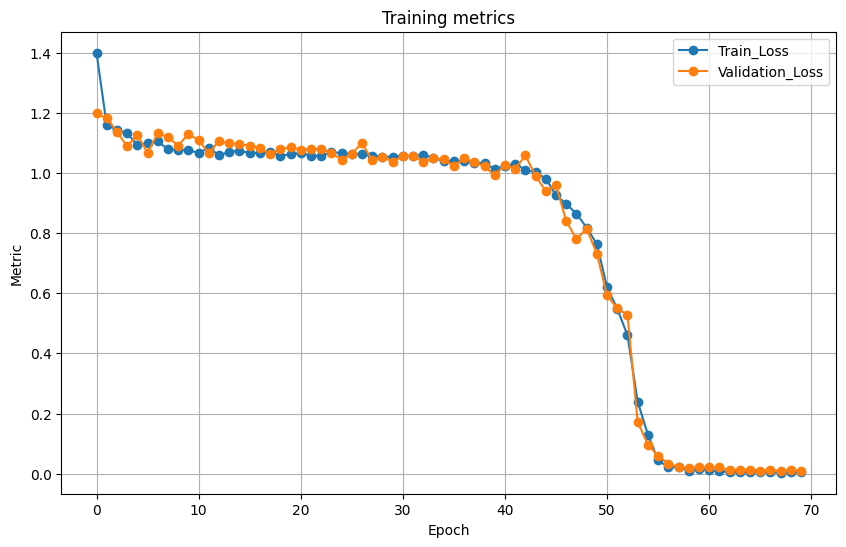

In [21]:
model = SupersimplenetModel(
        backbone="wide_resnet50_2.tv_in1k",
        layers=["layer2", "layer3"],
        perlin_threshold=0.2,
        stop_grad=True
    )

trained_model = train_ssn_with_validation(
    model=model,
    train_dataset=train_dataset,
    validation_dataset=normal_validation_dataset,
    segmentation_dataset=segmentation_val_dataset,
    classification_dataset=classification_val_dataset,
    visualization_dataset=visualization_dataset,
    num_epochs=num_train_epochs,
    learning_rate=1e-4,
    weight_decay=1e-5,
    device=device,
    log_interval=7,
    log_dir=log_dir,
    batch_size=10,
    resume_from_checkpoint=False,
    freeze_extractor=True,
    early_stopping_patience=12,
    early_stopping_metric="Validation_Loss",
    early_stopping_mode="min"
)


# Тестирование лучшей обученной модели


In [22]:
device="cuda" if torch.cuda.is_available() else "cpu"
print(device)
if torch.cuda.is_available():
    print(f"Название GPU: {torch.cuda.get_device_name(torch.cuda.current_device())}")
else:
    print("CUDA недоступна, обучение будет выполняться на CPU")


cuda
Название GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU


In [23]:
# Load the trained model from the selected try_N folder.
best_model_path = os.path.join(log_dir, "trained_model.pth")
best_trained_model = torch.load(best_model_path, map_location=device, weights_only=False)
best_trained_model.to(device)
best_trained_model.eval()

test_metrics = {}

needs_synthetic_segmentation = segmentation_test_dataset is None or len(segmentation_test_dataset) == 0
needs_synthetic_classification = classification_test_dataset is None or len(classification_test_dataset) == 0
synthetic_maps = []
synthetic_masks = []
synthetic_scores = []
synthetic_labels = []

needs_synthetic_segmentation = True
needs_synthetic_classification = True

# Printer anomaly fragments have image labels but no anomaly masks, so pixel-level real metrics stay disabled unless true anomaly masks are added.
# If either labeled test split is unavailable, generate one shared synthetic fallback pass.
# Synthetic maps and masks stay in feature resolution, matching the SSN training path.
if needs_synthetic_segmentation or needs_synthetic_classification:
    fallback_loader = DataLoader(normal_validation_dataset, batch_size=10, shuffle=False, num_workers=0)
    best_trained_model.train()
    with torch.no_grad():
        for batch in tqdm(fallback_loader, desc="Synthetic Test Fallback", leave=False):
            images = batch[0] if isinstance(batch, (list, tuple)) else batch
            images = images.to(device)
            pred_map, pred_score, target_mask, target_label = ssn_training_forward(best_trained_model, images)
            synthetic_maps.extend([pred.detach().cpu() for pred in torch.sigmoid(pred_map)])
            synthetic_masks.extend([mask.detach().cpu() for mask in target_mask])
            synthetic_scores.extend(pred_score.detach().view(-1).cpu().tolist())
            synthetic_labels.extend(target_label.detach().view(-1).cpu().tolist())
    best_trained_model.eval()

# Segmentation/localization test. If no labeled segmentation split is available,
# fall back to synthetic masks generated from held-out normal images.
if not needs_synthetic_segmentation:
    anomaly_maps = []
    true_masks = []
    defect_types = []
    with torch.no_grad():
        for i in tqdm(range(len(segmentation_test_dataset)), desc="Segmentation Test", leave=False):
            img, true_mask, defect_type, name = unpack_segmentation_sample(segmentation_test_dataset[i])
            img = img.unsqueeze(0).to(device)
            anomaly_map = predict_anomaly_map(
                best_trained_model,
                img,
                true_img_size=(true_mask.shape[-2], true_mask.shape[-1]),
                apply_sigmoid=True,
            )
            anomaly_maps.append(anomaly_map)
            true_masks.append(true_mask)
            defect_types.append(defect_type)

    test_metrics["pixel_aupro"] = pixel_aupro(anomaly_maps, true_masks)
    test_metrics.update(pixel_aupro_by_class(anomaly_maps, true_masks, defect_types))

    visualization_dir = os.path.join(log_dir, "test_visualizations")
    save_validation_visualizations(best_trained_model, segmentation_test_dataset, visualization_dir, device=device)
else:
    test_metrics["synthetic_pixel_aupro"] = pixel_aupro(synthetic_maps, synthetic_masks)

# Image-level detection test. If no labeled classification split is available,
# fall back to synthetic labels generated from held-out normal images.
if not needs_synthetic_classification:
    predicted_scores = []
    true_labels = []
    defect_types = []
    with torch.no_grad():
        for i in tqdm(range(len(classification_test_dataset)), desc="Classification Test", leave=False):
            img, true_label, defect_type, name = unpack_classification_sample(classification_test_dataset[i])
            img = img.unsqueeze(0).to(device)
            img_score = predict_image_score(best_trained_model, img, apply_sigmoid=False)

            predicted_scores.append(img_score)
            true_labels.append(true_label)
            defect_types.append(defect_type)

    if len(set(true_labels)) > 1:
        test_metrics["image_roc_auc_raw"] = roc_auc_score(true_labels, predicted_scores)
        test_metrics.update(image_roc_auc_by_class(predicted_scores, true_labels, defect_types))
    else:
        test_metrics["image_roc_auc_raw"] = float("nan")
else:
    if len(set(synthetic_labels)) > 1:
        test_metrics["synthetic_image_roc_auc_raw"] = roc_auc_score(synthetic_labels, synthetic_scores)
    else:
        test_metrics["synthetic_image_roc_auc_raw"] = float("nan")

save_unlabeled_visualizations(
    best_trained_model,
    anomaly_visualization_dataset,
    os.path.join(log_dir, "test_anomaly_visualizations"),
    device=device,
    max_items=32,
    prefix="printer_anomaly",
)

with open(os.path.join(log_dir, "test_metrics.txt"), "w") as f:
    for metric_name, metric_value in test_metrics.items():
        f.write(f"{metric_name}: {metric_value}\n")

for metric_name, metric_value in test_metrics.items():
    print(f"{metric_name}: {metric_value}")

synthetic_pixel_aupro: 0.9999390840530396
synthetic_image_roc_auc_raw: 0.9999999999999999
